# Phase-2 bare-bones explorer

Single diffusion time (`m = 1`), one parameter coordinate, no downstream
restrictions unless you switch them on.

1. **Setup** - constants and functions.
2. **Choose and compute** - the knobs, then load / build.
3. **View** - tables and plots.

All acquisition limits (`G_MAX`, `TRUST_FLOOR`, `RICIAN_MIN`, `AVERAGES`) live in
section 2 and default to **off**, and turning them off really does expose every
stored column: the Phase-1 substrate spans the full `(delta, Delta, b)` grid and
section 1 asserts it. See `docs/fisher_domain_audit.md`.

## 1. Setup

In [1]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO       = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
ARTIFACT   = REPO / "data/libraries/madi_dense_universal_remediated.npz"
PHASE1_DIR = Path("/home/jaden/madi_fisher_runs/full_domain/phase1")
CACHE_DIR  = Path("/home/jaden/madi_fisher_runs/full_domain/cache")

sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))
from madi.fisher_crlb import (PARAMETER_ORDER, canonical_grid, column_arrays, fisher_diagnostics,
                              fisher_matrix, gradient_strength_t_per_m, pack_fisher,
                              packed_amplitude_marginal, packed_inverse_diagonal, read_column_domain,
                              te_noise_sigma, unpack_fisher)
from run_fisher_phase2 import build_node_table, transposed_view

np.set_printoptions(precision=5, linewidth=140)

In [2]:
# ---- load: library labels, node table, column-major signal caches -----------
with np.load(ARTIFACT, allow_pickle=False) as d:
    PAIR_D  = np.asarray(d["pair_deltas"], float)      # small delta, ms
    PAIR_DD = np.asarray(d["pair_Deltas"], float)      # big Delta, ms
    B_VALUES = np.asarray(d["b_values"], float)        # s/mm^2
    N_B = int(d["n_b"])
    TABLE = build_node_table(PHASE1_DIR, d)            # nodes with all three k=1 stencils

VECTORS  = transposed_view(CACHE_DIR, "vectors")           # (column, entry)  S/S0
VARIANCE = transposed_view(CACHE_DIR, "signal_variance")   # (column, entry)  var of ensemble MEANS
N_ENS    = int(np.load(CACHE_DIR / "ensemble_means_subset.npy", mmap_mode="r").shape[1])

# The Phase-1 substrate spans every stored column, and this asserts it rather
# than trusting it: before 2026-09-06 it did not, so setting G_MAX = inf below
# could not recover the gradient-infeasible columns.  See docs/fisher_domain_audit.md.
DOMAIN   = read_column_domain(json.loads((PHASE1_DIR / "phase1_manifest.json").read_text()))
print(DOMAIN.banner())
assert DOMAIN.is_complete, "this notebook reads the model, so it needs the unrestricted substrate"
SELECTED = np.asarray(DOMAIN.column_indices, int)
POSITION = DOMAIN.position_of

RHOS, VS, KIOS, _ = canonical_grid()
NODE_RHO, NODE_V, NODE_KIO = TABLE["rho"], TABLE["V"], TABLE["kio"]
N_NODES = len(TABLE["nodes"])
AXES = ("rho", "V", "k_io")

D_COL, DD_COL, B_COL = column_arrays(PAIR_D, PAIR_DD, B_VALUES)
GRAD_COL = gradient_strength_t_per_m(D_COL, DD_COL, B_COL)   # T/m per full column

print(f"{N_NODES} nodes | {len(PAIR_D)} timing pairs x {N_B} b | n_ensembles={N_ENS}")
print(f"rho {RHOS.min():.3g}..{RHOS.max():.3g} cells/uL | V {VS.min():.3g}..{VS.max():.3g} pL "
      f"| k_io {KIOS.min():g}..{KIOS.max():g} 1/s")

COLUMN DOMAIN COMPLETE — all 31125 stored (delta, Delta, b) columns
11417 nodes | 1245 timing pairs x 25 b | n_ensembles=40
rho 1e+04..1e+07 cells/uL | V 0.01..200 pL | k_io 0..130 1/s


In [3]:
# ---- functions -------------------------------------------------------------

def node_at(rho, V, k_io):
    """Nearest node. rho/V matched in log space (both grids span decades)."""
    c = ((np.log(NODE_RHO) - math.log(rho)) / np.ptp(np.log(NODE_RHO))) ** 2 \
      + ((np.log(NODE_V) - math.log(V)) / np.ptp(np.log(NODE_V))) ** 2 \
      + ((NODE_KIO - k_io) / np.ptp(NODE_KIO)) ** 2
    return int(np.argmin(c))


def pair_at(delta, Delta):
    """Nearest stored timing pair index."""
    return int(np.argmin((PAIR_D - delta) ** 2 + (PAIR_DD - Delta) ** 2))


def columns_at(pair, b_min=0.0, b_max=np.inf, g_max=np.inf, drop_b0=True):
    """Cache positions for one timing pair, filtered only by what you ask for."""
    full = pair * N_B + np.arange(N_B)
    keep = (POSITION[full] >= 0) & (B_COL[full] >= b_min) & (B_COL[full] <= b_max) \
         & (GRAD_COL[full] <= g_max)
    if drop_b0:
        keep &= B_COL[full] > 0          # S(0)=1 for every entry, so J == 0 there
    return POSITION[full[keep]]


def analyze(node, pair, columns, averages=1.0, snr=50.0, T2=80.0, t_epi=0.0,
            trust_floor=0.0, rician_min=0.0, debias=True, n0_eff=None, kio_floor=1.0):
    """Everything at one node for one single-Delta acquisition."""
    S    = np.asarray(VECTORS[columns],  np.float64)   # (n_col, entries)
    Svar = np.asarray(VARIANCE[columns], np.float64)
    step = np.asarray([TABLE[f"step_{a}"][node] for a in AXES])   # dlogrho, dlogV, dk_io

    S_c  = S[:, TABLE["centre"][node]]
    Sm   = np.stack([S[:,    TABLE[f"minus_{a}"][node]] for a in AXES], -1)
    Sp   = np.stack([S[:,    TABLE[f"plus_{a}"][node]]  for a in AXES], -1)
    Vm   = np.stack([Svar[:, TABLE[f"minus_{a}"][node]] for a in AXES], -1)
    Vp   = np.stack([Svar[:, TABLE[f"plus_{a}"][node]]  for a in AXES], -1)

    J     = (Sp - Sm) / step                              # dS/d(log rho, log V, k_io)
    var_J = (Vp + Vm) / (N_ENS * step ** 2)               # endpoint-only; OVERSTATES (drops CRN cov)
    beta  = np.divide(var_J, J ** 2, out=np.full_like(var_J, np.inf), where=J != 0)

    sigma_1 = float(te_noise_sigma(PAIR_D[pair], PAIR_DD[pair], sigma0=1/snr, T2_ms=T2, t_epi_ms=t_epi))
    sigma   = sigma_1 / math.sqrt(averages)
    keep    = (S_c >= trust_floor) & (S_c >= rician_min * sigma)

    F   = fisher_matrix(J, sigma, var_J if debias else None, keep)
    F_u = fisher_matrix(J, sigma, None, keep)
    if n0_eff is not None:                                # marginalise unknown S0
        u = np.where(keep, 1/sigma**2, 0.0)
        F = unpack_fisher(packed_amplitude_marginal(
            pack_fisher(F), (J * (u * S_c)[:, None]).sum(0), float((u * S_c**2).sum()),
            float(n0_eff) / sigma_1**2))

    kio_ref = max(float(NODE_KIO[node]), kio_floor)
    dg      = fisher_diagnostics(F, kio_ref)
    ok      = bool(packed_inverse_diagonal(pack_fisher(F))[2])
    crlb    = dg["crlb"]  if ok else np.full(3, np.inf)   # not PD -> no bound (0.0 would lie)
    kappa   = dg["kappa"] if ok else np.full(3, np.inf)
    return dict(node=node, pair=pair, columns=columns, b=B_COL[SELECTED[columns]],
                gradient=GRAD_COL[SELECTED[columns]], step=step, sigma_1=sigma_1, sigma=sigma,
                S=S_c, J=J, var_J=var_J, beta=beta, keep=keep, F=F, F_undebiased=F_u,
                Finv=dg["Finv"], crlb=crlb, relative_crlb=np.array([crlb[0], crlb[1], crlb[2]/kio_ref]),
                kappa=kappa, identifiable=ok, eig=dg["F_tilde_eigenvalues"],
                eigvec=dg["F_tilde_eigenvectors"], kio_ref=kio_ref)


_P1 = {}
def r_trunc(node):
    """|J_k1 - Richardson|/|J_k1| over all selected columns. rho and V only.

    k_io was pre-registered at k=1 alone, so it has no k=2 companion.  Returns
    None for an axis this node has no k1/k2 overlap on.
    """
    out = {}
    for axis in ("rho", "V"):
        key = tuple(int(v) for v in TABLE["nodes"][node])
        if axis not in _P1:
            s = np.load(PHASE1_DIR / f"samples_Richardson_{axis}_k1_k2.npy")
            _P1[axis] = {tuple(int(v) for v in r): i for i, r in enumerate(s)}
        row = _P1[axis].get(key)
        if row is None:
            out[axis] = None; continue
        J1  = np.asarray(np.load(PHASE1_DIR / f"J_{axis}_k1.npy", mmap_mode="r")
                         [int(TABLE["phase1_rows"][axis][node])], np.float64)
        imp = np.asarray(np.load(PHASE1_DIR / f"Richardson_{axis}_k1_k2.npy", mmap_mode="r")[row], np.float64)
        with np.errstate(divide="ignore", invalid="ignore"):
            out[axis] = np.where(J1 != 0, np.abs(J1 - imp) / np.abs(J1), np.nan)
    out["k_io"] = None
    return out

## 2. Choose and compute

Everything you would want to change is here. All limits default to **off**:
`G_MAX = inf`, `TRUST_FLOOR = 0`, `RICIAN_MIN = 0`, `AVERAGES = 1`.

In [25]:
# ---- parameter coordinate --------------------------------------------------
RHO   = 2.5e5     # cells/uL   (grid 1e4 .. 1e7)
V     = 4.0       # pL         (grid 0.01 .. 200)
K_IO  = 10.0      # 1/s        (grid 0 .. 130, NON-uniform spacing)

# ---- single diffusion time -------------------------------------------------
DELTA, BIG_DELTA = 6.0, 20.0     # ms

# ---- column selection (all off by default) ---------------------------------
B_MIN, B_MAX = 0.0, 2500       # s/mm^2
G_MAX        = np.inf             # T/m       -- 0.08 clinical / 0.30 research to condition on hardware
DROP_B0      = True               # J is identically 0 at b=0

# ---- noise / masks (all off by default) ------------------------------------
SNR, T2_MS, T_EPI_MS = 50.0, 80.0, 0.0
AVERAGES     = 1.0                # n_c per column
TRUST_FLOOR  = 0.0                # was 0.015
RICIAN_MIN   = 0.0                # was 3.0  (needs S >= RICIAN_MIN * sigma)

# ---- model options ---------------------------------------------------------
DEBIAS  = False                    # subtract Var(J_hat) from the Fisher diagonal
N0_EFF  = None                    # None = S0 known exactly; 0 = S0 fully unknown

NODE = node_at(RHO, V, K_IO)
PAIR = pair_at(DELTA, BIG_DELTA)
COLS = columns_at(PAIR, B_MIN, B_MAX, G_MAX, DROP_B0)
R    = analyze(NODE, PAIR, COLS, AVERAGES, SNR, T2_MS, T_EPI_MS,
               TRUST_FLOOR, RICIAN_MIN, DEBIAS, N0_EFF)
RT   = r_trunc(NODE)

print(f"node {NODE}: rho={NODE_RHO[NODE]:.4g} cells/uL  V={NODE_V[NODE]:.4g} pL  "
      f"k_io={NODE_KIO[NODE]:.4g} 1/s  v_i={NODE_RHO[NODE]*NODE_V[NODE]*1e-6:.4f}")
print(f"pair {PAIR}: delta={PAIR_D[PAIR]:.1f}  Delta={PAIR_DD[PAIR]:.1f} ms  "
      f"TE={PAIR_D[PAIR]+PAIR_DD[PAIR]+T_EPI_MS:.1f} ms  sigma={R['sigma']:.5f}")
print(f"{len(COLS)} columns, {int(R['keep'].sum())} kept by masks")
print(f"steps: dlog(rho)={R['step'][0]:.5f}  dlog(V)={R['step'][1]:.5f}  dk_io={R['step'][2]:.5f}")

node 5301: rho=2.404e+05 cells/uL  V=3.357 pL  k_io=10 1/s  v_i=0.8071
pair 284: delta=6.0  Delta=20.0 ms  TE=26.0 ms  sigma=0.02768
5 columns, 5 kept by masks
steps: dlog(rho)=0.21979  dlog(V)=0.31458  dk_io=2.00000


## 3. View

In [27]:
# ---- per-column table ------------------------------------------------------
hdr = f"{'b':>7}{'G':>7}{'S':>9}{'keep':>6} |{'J_logrho':>11}{'J_logV':>11}{'J_kio':>12} |" \
      f"{'beta_rho':>10}{'beta_V':>10}{'beta_kio':>10} |{'rtr_rho':>9}{'rtr_V':>9}"
print(hdr); print("-" * len(hdr))
for i, c in enumerate(COLS):
    rr = f"{RT['rho'][c]:9.2e}" if RT['rho'] is not None else f"{'--':>9}"
    rv = f"{RT['V'][c]:9.2e}"   if RT['V']   is not None else f"{'--':>9}"
    print(f"{R['b'][i]:7.0f}{R['gradient'][i]:7.3f}{R['S'][i]:9.5f}{str(bool(R['keep'][i])):>6} |"
          f"{R['J'][i,0]:11.5f}{R['J'][i,1]:11.5f}{R['J'][i,2]:12.3e} |"
          f"{R['beta'][i,0]:10.2e}{R['beta'][i,1]:10.2e}{R['beta'][i,2]:10.2e} |{rr}{rv}")

      b      G        S  keep |   J_logrho     J_logV       J_kio |  beta_rho    beta_V  beta_kio |  rtr_rho    rtr_V
---------------------------------------------------------------------------------------------------------------------
    500  0.104  0.57063  True |    0.26267    0.14748  -3.727e-03 |  7.22e-05  1.13e-04  4.54e-03 |       --       --
   1000  0.147  0.34369  True |    0.25477    0.11490  -4.247e-03 |  1.25e-04  2.98e-04  5.44e-03 |       --       --
   1500  0.180  0.21658  True |    0.19387    0.06414  -3.744e-03 |  2.22e-04  9.65e-04  7.02e-03 |       --       --
   2000  0.208  0.14206  True |    0.13709    0.02863  -3.032e-03 |  3.92e-04  4.30e-03  9.15e-03 |       --       --
   2500  0.232  0.09680  True |    0.09503    0.00896  -2.382e-03 |  6.88e-04  3.84e-02  1.23e-02 |       --       --


In [28]:
# ---- Fisher matrix and bounds ----------------------------------------------
F = R["F"]

print("F (debias=%s, n0_eff=%s)" % (DEBIAS, N0_EFF))
print(f"{'':>9}" + "".join(f"{n:>16}" for n in PARAMETER_ORDER))
for i, n in enumerate(PARAMETER_ORDER):
    print(f"{n:>9}" + "".join(f"{F[i,j]:16.6g}" for j in range(3)))

shift = np.diag(R["F_undebiased"]) - np.diag(F)
print(f"\ndebias removed from diagonal : {shift}")
print(f"  as a fraction of undebiased: "
      f"{shift / np.diag(R['F_undebiased'])}")


# ---- Rank / singularity diagnostics ----------------------------------------
rank = np.linalg.matrix_rank(F)
det = np.linalg.det(F)
cond = np.linalg.cond(F)

# Fisher matrix should be symmetric, so eigvalsh is preferred
eigvals = np.linalg.eigvalsh(F)

# Singular values are another robust way to inspect near-singularity
singular_values = np.linalg.svd(F, compute_uv=False)

print("\n--- Fisher matrix diagnostics ---")
print(f"shape                 : {F.shape}")
print(f"rank                  : {rank} / {F.shape[0]}")
print(f"full rank             : {rank == F.shape[0]}")
print(f"det(F)                : {det:.6g}")
print(f"condition number      : {cond:.6g}")

print(f"eigenvalues           : {eigvals}")
print(f"smallest eigenvalue   : {eigvals.min():.6g}")
print(f"largest eigenvalue    : {eigvals.max():.6g}")

print(f"singular values       : {singular_values}")
print(f"smallest singular val : {singular_values.min():.6g}")

print(f"positive definite     : {np.all(eigvals > 0)}")

if rank < F.shape[0]:
    print("WARNING: F is rank deficient -> not invertible.")
elif cond > 1e12:
    print("WARNING: F is full rank but extremely ill-conditioned.")
elif cond > 1e8:
    print("WARNING: F is poorly conditioned; CRLB may be numerically unstable.")
else:
    print("F appears numerically invertible.")


# ---- CRLB ------------------------------------------------------------------
print(f"\n{'':>9}{'CRLB':>16}{'rel CRLB':>16}{'kappa':>12}")
for i, n in enumerate(PARAMETER_ORDER):
    print(
        f"{n:>9}"
        f"{R['crlb'][i]:16.6g}"
        f"{R['relative_crlb'][i]:16.6g}"
        f"{R['kappa'][i]:12.4g}"
    )

print(f"\nidentifiable (F positive definite): {R['identifiable']}")

if not R["identifiable"]:
    print(
        "  -> no finite bound exists here; "
        "CRLB/kappa are reported as inf, not 0."
    )


# ---- Scaled-F eigen diagnostics --------------------------------------------
print(f"\neigenvalues of k_io-scaled F: {R['eig']}")

scaled_cond = (
    R["eig"].max()
    / max(R["eig"].min(), 1e-300)
)

print(f"condition number (scaled F): {scaled_cond:.4g}")

print(
    "smallest-eigenvalue direction "
    "(log_rho, log_V, k_io*): "
    f"{R['eigvec'][:, 0]}"
)

F (debias=False, n0_eff=None)
                  log_rho           log_V            k_io
  log_rho         260.125         111.229         -4.4751
    log_V         111.229         52.1638        -1.80895
     k_io         -4.4751        -1.80895       0.0793676

debias removed from diagonal : [0. 0. 0.]
  as a fraction of undebiased: [0. 0. 0.]

--- Fisher matrix diagnostics ---
shape                 : (3, 3)
rank                  : 3 / 3
full rank             : True
det(F)                : 0.00183438
condition number      : 2.01567e+08
eigenvalues           : [1.53042e-06 3.88553e+00 3.08482e+02]
smallest eigenvalue   : 1.53042e-06
largest eigenvalue    : 308.482
singular values       : [3.08482e+02 3.88553e+00 1.53042e-06]
smallest singular val : 1.53042e-06
positive definite     : True

                     CRLB        rel CRLB       kappa
  log_rho         21.7507         21.7507       350.8
    log_V         18.3685         18.3685       132.7
     k_io         807.841         80.

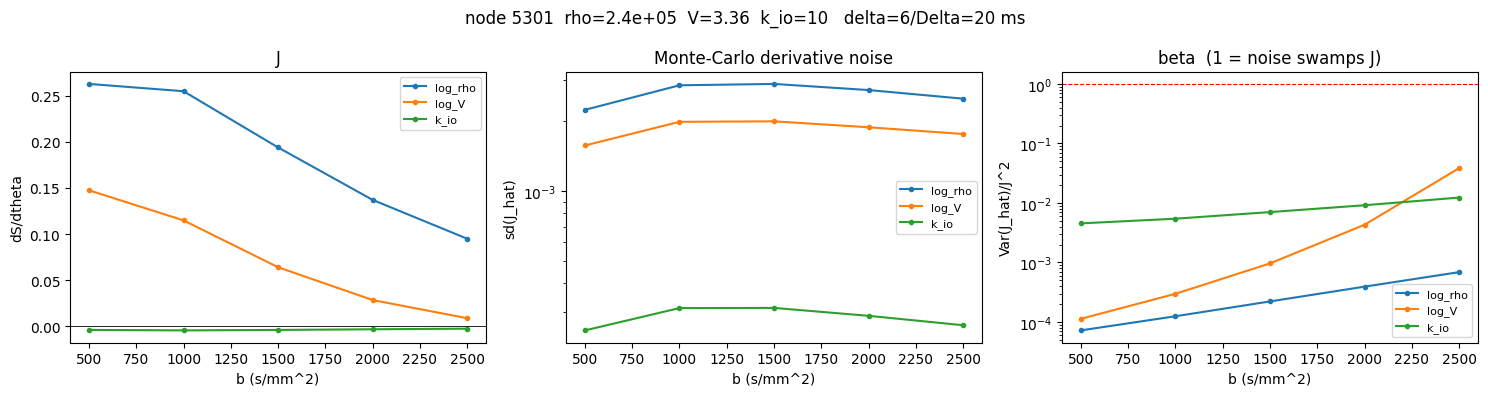

In [29]:
# ---- J, derivative noise, beta vs b ----------------------------------------
o = np.argsort(R["b"]); b = R["b"][o]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for j, n in enumerate(PARAMETER_ORDER):
    ax[0].plot(b, R["J"][o, j], "o-", ms=3, label=n)
    ax[1].semilogy(b, np.sqrt(R["var_J"][o, j]), "o-", ms=3, label=n)
    ax[2].semilogy(b, R["beta"][o, j], "o-", ms=3, label=n)
ax[0].axhline(0, c="k", lw=.6); ax[2].axhline(1, c="r", ls="--", lw=.8)
ax[0].set(xlabel="b (s/mm^2)", ylabel="dS/dtheta", title="J")
ax[1].set(xlabel="b (s/mm^2)", ylabel="sd(J_hat)", title="Monte-Carlo derivative noise")
ax[2].set(xlabel="b (s/mm^2)", ylabel="Var(J_hat)/J^2", title="beta  (1 = noise swamps J)")
for a in ax: a.legend(fontsize=8)
if (~R["keep"]).any():
    for a in ax:
        for x in b[~R["keep"][o]]: a.axvline(x, c="0.88", lw=5, zorder=0)
fig.suptitle(f"node {NODE}  rho={NODE_RHO[NODE]:.3g}  V={NODE_V[NODE]:.3g}  k_io={NODE_KIO[NODE]:.3g}"
             f"   delta={PAIR_D[PAIR]:.0f}/Delta={PAIR_DD[PAIR]:.0f} ms")
fig.tight_layout()

k_io: no Richardson companion (pre-registered at k=1 only).


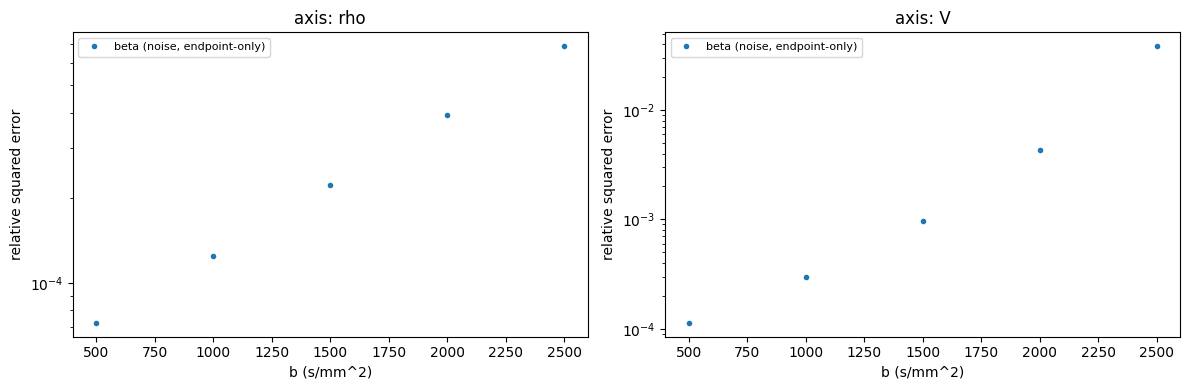

In [30]:
# ---- noise vs truncation (the stencil-width trade-off), rho and V ----------
# beta and r_trunc^2 are both relative SQUARED errors, so they compare directly.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, axis, j in zip(ax, ("rho", "V"), (0, 1)):
    a.semilogy(b, R["beta"][o, j], ".", label="beta (noise, endpoint-only)")
    if RT[axis] is not None:
        a.semilogy(b, RT[axis][COLS][o] ** 2, ".", label="r_trunc^2 (k=1)")
        a.semilogy(b, (4 * RT[axis][COLS][o]) ** 2, ".", alpha=.5, label="r_trunc^2 (k=2, 4x)")
    else:
        a.set_title(f"{axis}: no k1/k2 overlap at this node")
    a.set(xlabel="b (s/mm^2)", ylabel="relative squared error", title=f"axis: {axis}")
    a.legend(fontsize=8)
fig.tight_layout()
print("k_io: no Richardson companion (pre-registered at k=1 only).")

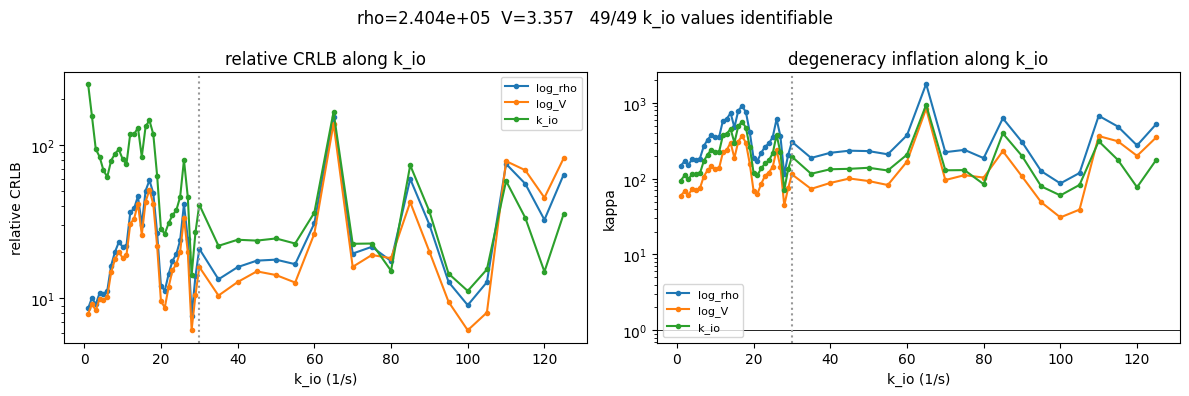

In [31]:
# ---- sweep k_io at this (rho, V) -------------------------------------------
ir, iv = TABLE["nodes"][NODE][0], TABLE["nodes"][NODE][1]
sweep = np.flatnonzero((TABLE["nodes"][:, 0] == ir) & (TABLE["nodes"][:, 1] == iv))
rows = [analyze(int(n), PAIR, COLS, AVERAGES, SNR, T2_MS, T_EPI_MS,
                TRUST_FLOOR, RICIAN_MIN, DEBIAS, N0_EFF) for n in sweep]
kio  = NODE_KIO[sweep]
rel  = np.array([r["relative_crlb"] for r in rows])
kap  = np.array([r["kappa"] for r in rows])
ok   = np.array([r["identifiable"] for r in rows])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for j, n in enumerate(PARAMETER_ORDER):
    ax[0].semilogy(kio[ok], rel[ok, j], "o-", ms=3, label=n)
    ax[1].semilogy(kio[ok], kap[ok, j], "o-", ms=3, label=n)
ax[0].set(xlabel="k_io (1/s)", ylabel="relative CRLB", title="relative CRLB along k_io")
ax[1].axhline(1, c="k", lw=.6)
ax[1].set(xlabel="k_io (1/s)", ylabel="kappa", title="degeneracy inflation along k_io")
for a in ax: a.legend(fontsize=8); a.axvline(30, c="0.6", ls=":")
fig.suptitle(f"rho={NODE_RHO[NODE]:.4g}  V={NODE_V[NODE]:.4g}   "
             f"{int(ok.sum())}/{len(sweep)} k_io values identifiable")
fig.tight_layout()

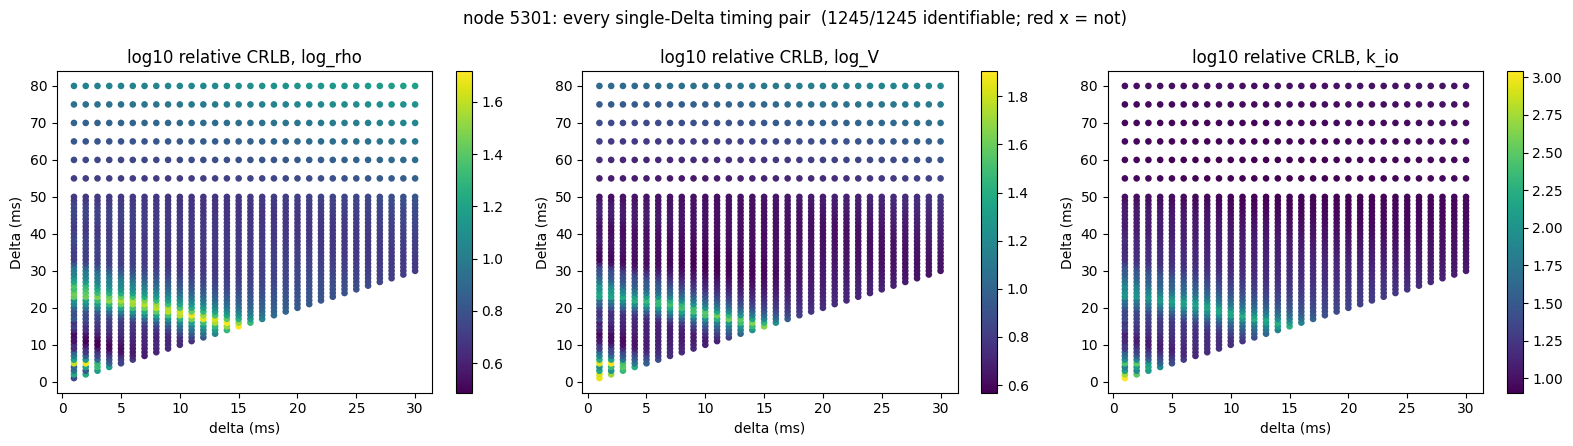

In [32]:
# ---- sweep timing pairs at this node ---------------------------------------
res = []
for p in range(len(PAIR_D)):
    c = columns_at(p, B_MIN, B_MAX, G_MAX, DROP_B0)
    if len(c) < 3: continue
    r = analyze(NODE, p, c, AVERAGES, SNR, T2_MS, T_EPI_MS,
                TRUST_FLOOR, RICIAN_MIN, DEBIAS, N0_EFF)
    res.append((PAIR_D[p], PAIR_DD[p], *r["relative_crlb"], r["identifiable"]))
res = np.array(res)
good = res[:, 5].astype(bool)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for j, n in enumerate(PARAMETER_ORDER):
    s = ax[j].scatter(res[good, 0], res[good, 1], c=np.log10(res[good, 2 + j]), s=14, cmap="viridis")
    ax[j].scatter(res[~good, 0], res[~good, 1], c="crimson", s=8, marker="x")
    ax[j].set(xlabel="delta (ms)", ylabel="Delta (ms)", title=f"log10 relative CRLB, {n}")
    plt.colorbar(s, ax=ax[j])
fig.suptitle(f"node {NODE}: every single-Delta timing pair  "
             f"({int(good.sum())}/{len(res)} identifiable; red x = not)")
fig.tight_layout()